## Preprocessing

In [1]:
from sklearn.model_selection import train_test_split, cross_validate,cross_val_score, GridSearchCV, StratifiedKFold

# Models
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import StackingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

# Metrics
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score, accuracy_score
from sklearn.metrics import PrecisionRecallDisplay, average_precision_score, precision_recall_curve
from sklearn.metrics import RocCurveDisplay, roc_auc_score, roc_curve, auc
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

from yellowbrick.classifier import PrecisionRecallCurve, ClassPredictionError, ROCAUC
from yellowbrick.regressor import ResidualsPlot, PredictionError

import warnings
warnings.filterwarnings('ignore', category=UserWarning)

distutils was removed in Python 3.12+, and yellowbrick hasn't been updated to support Python 3.14 yet. 
## pip install setuptools

## Load Data

In [ ]:
df = pd.read_csv("../../data/processed/url_dataset.csv")
df.columns = df.columns.str.lower()

print(f'Data shape (rows,columns): {df.shape}')
print('\n')
print(f'Number of Duplicate rows: {df.duplicated().sum()}')
print("\n")
print(f'Number of missing values: {df.isnull().sum().sum()}')
print("\n")

Data shape (rows,columns): (1353, 10)


Number of Duplicate rows: 629


Number of missing values: 0




In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1353 entries, 0 to 1352
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   sfh                1353 non-null   str  
 1   popupwidnow        1353 non-null   str  
 2   sslfinal_state     1353 non-null   str  
 3   request_url        1353 non-null   str  
 4   url_of_anchor      1353 non-null   str  
 5   web_traffic        1353 non-null   str  
 6   url_length         1353 non-null   str  
 7   age_of_domain      1353 non-null   str  
 8   having_ip_address  1353 non-null   str  
 9   result             1353 non-null   str  
dtypes: str(10)
memory usage: 105.8 KB


## Converting Datatype Object to int64  

In [4]:
import re

def clean_to_int(x):
    if isinstance(x, bytes):
        return int(x.decode())
    if isinstance(x, str):
        # Match negative and positive numbers inside possible b'' or quotes
        match = re.match(r"b?'?\"?(-?\d+)'?\"?", x)
        if match:
            return int(match.group(1))
        # If not matching, try direct conversion
        try:
            return int(x)
        except ValueError:
            return None  # or np.nan if you want to handle missing values
    return int(x)

# Apply cleaning only to columns that should be int
cols = ['sfh', 'popupwidnow', 'sslfinal_state', 'request_url', 'url_of_anchor',
        'web_traffic', 'url_length', 'age_of_domain', 'having_ip_address', 'result']

df[cols] = df[cols].map(clean_to_int)
df = df.astype('int64')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1353 entries, 0 to 1352
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   sfh                1353 non-null   int64
 1   popupwidnow        1353 non-null   int64
 2   sslfinal_state     1353 non-null   int64
 3   request_url        1353 non-null   int64
 4   url_of_anchor      1353 non-null   int64
 5   web_traffic        1353 non-null   int64
 6   url_length         1353 non-null   int64
 7   age_of_domain      1353 non-null   int64
 8   having_ip_address  1353 non-null   int64
 9   result             1353 non-null   int64
dtypes: int64(10)
memory usage: 105.8 KB


## Train | Test Split

In [5]:
#Splitting Data
X = df.drop('result', axis = 1)
y = df['result']

# Merge labels: suspicious (0) and phishing (-1) into phishing (0), legitimate (1) remains 1
y = y.replace({-1: 0, 0: 0, 1: 1})

# Now split again (since y changed)
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.2,
                                                    stratify=y,
                                                    random_state=42)

# Encode to binary (0=phishing, 1=legitimate)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)  # Also encode y_test for consistency

print('---------------------------------------------')
print("X_Train rows-columns: ", X_train.shape)
print("y_Train Target Feature rosw: ", y_train.shape)
print("X_Test Validation Data rows-columns: ", X_test.shape)
print('---------------------------------------------')
print("Prediction Test Dataset rows-columns: ", y_test.shape)
print('---------------------------------------------')

---------------------------------------------
X_Train rows-columns:  (1082, 9)
y_Train Target Feature rosw:  (1082,)
X_Test Validation Data rows-columns:  (271, 9)
---------------------------------------------
Prediction Test Dataset rows-columns:  (271,)
---------------------------------------------


In [6]:
X_train.head(3)

,sfh,popupwidnow,sslfinal_state,request_url,url_of_anchor,web_traffic,url_length,age_of_domain,having_ip_address
856,1,-1,0,1,1,0,-1,1,0
1297,1,0,1,-1,1,0,1,-1,0
1296,1,0,-1,1,1,1,1,-1,0


In [7]:
X_test.head(3)

,sfh,popupwidnow,sslfinal_state,request_url,url_of_anchor,web_traffic,url_length,age_of_domain,having_ip_address
673,1,0,1,1,1,1,1,1,1
552,1,0,1,-1,1,0,0,-1,0
226,1,1,1,-1,-1,-1,1,1,0


## User Defined Functions

In [8]:
# User-Defined-Functions

#-----------------------------------------------------

# Function to Evaluate the Model Performans using Classification Confusion_matrix() 
# Also does the prediction in the function

def eval_metric(model, X_train, y_train, X_test, y_test, i):

    """ to get the metrics for the model """

    y_train_pred = model.predict(X_train)
    y_pred = model.predict(X_test)
    
    print(f"{i} Test_Set")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    print()
    print(f"{i} Train_Set")
    print(confusion_matrix(y_train, y_train_pred))
    print(classification_report(y_train, y_train_pred))
    
# -----------------------------------------------------

# Function to display Feature Importance
def plot_feature_importance(model, X_train, model_name, figsize=(8, 5)):
    """
    Plots the feature importances of a fitted model as a horizontal bar plot,
    with the importance values displayed next to the bars.
    """
    # Get feature importances
    feature_importances = model.feature_importances_
    
    # Create a Series for feature importances
    feats = pd.Series(data=feature_importances, index=X_train.columns).sort_values(ascending=False)
    
    # Plot the feature importances as a horizontal bar plot
    plt.figure(figsize=figsize)
    sns.barplot(y=feats.index, x=feats.values, orient='h', palette='Blues')

    # Add the importance values next to the bars
    for index, value in enumerate(feats.values):
        plt.text(value, index, f'{value:.2f}', va='center', fontsize=10)

    # Add model name to the plot title
    plt.title(f"Feature Importances - {model_name}")
    plt.xlabel("Importance")
    plt.ylabel("Features")
    plt.show()

## Modeling

- We will compare 10 popular classifiers and evaluate the mean accuracy of each of them by a stratified k-fold cross-validation procedure.
    - Lojistik Regresyon
    - Support Vector Classifier (SVC)
    - K-Nearest Neighbors (KNN)
    - Multiple Layer Perceptron (Sinir Ağı)
    - Linear Discriminant Analysis (LDA)
    - Decision Tree
    - Random Forest
    - AdaBoost
    - XGBoost
    - LightGBM

# Base Models

In [9]:
from sklearn.preprocessing import LabelEncoder

# le = LabelEncoder()
# y_train = le.fit_transform(y_train)

# Comparing the Classifier Models

random_state = 42 #for reproducibility

kfold = StratifiedKFold(n_splits=10)

classifiers = []

classifiers.append(LogisticRegression(
    random_state=random_state, 
    max_iter=1000))

classifiers.append(SVC(
    random_state=random_state))

classifiers.append(KNeighborsClassifier())

classifiers.append(DecisionTreeClassifier(
    random_state=random_state))

classifiers.append(RandomForestClassifier(
    random_state=random_state))

classifiers.append(AdaBoostClassifier(
    DecisionTreeClassifier(random_state=random_state),
    random_state=random_state,
    learning_rate=0.1))

classifiers.append(XGBClassifier(
    random_state=random_state,
    eval_metric="mlogloss",
    use_label_encoder=False))

classifiers.append(LGBMClassifier(random_state=random_state))

classifiers.append(MLPClassifier(random_state=random_state))

classifiers.append(LinearDiscriminantAnalysis())

cv_results = []
for classifier in classifiers :
    cv_results.append(cross_val_score(classifier, 
                                      X_train, 
                                      y = y_train, 
                                      scoring = "accuracy", 
                                      cv = kfold, n_jobs=4,verbose=1))

cv_means = []
cv_std = []
for cv_result in cv_results:
    cv_means.append(cv_result.mean())
    cv_std.append(cv_result.std())

cv_res = pd.DataFrame({"Algorithm":["LogisticRegression","SVC","KNeighbors",
"DecisionTree","RandomForest","AdaBoost","XGBoost","LightGBM","MultipleLayerPerceptron","LinearDiscriminantAnalysis"],
"CrossValMeans":cv_means,"CrossValerrors": cv_std,})

[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  10 out of  10 | elapsed:    1.7s finished
[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  10 out of  10 | elapsed:    0.0s finished
[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  10 out of  10 | elapsed:    0.1s finished
[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  10 out of  10 | elapsed:    0.0s finished
[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  10 out of  10 | elapsed:    0.3s finished
[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  10 out of  10 | elapsed:    0.2s finished
[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  10 out of  10 | elapsed:   

[LightGBM] [Info] Number of positive: 394, number of negative: 580
[LightGBM] [Info] Number of positive: 394, number of negative: 580[LightGBM] [Info] Number of positive: 394, number of negative: 579

[LightGBM] [Info] Number of positive: 394, number of negative: 579
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000894 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000908 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000911 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000924 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 26[LightGBM] [Info] Total Bins 26

[LightGBM] [Info] To

[Parallel(n_jobs=4)]: Done  10 out of  10 | elapsed:    3.9s finished
[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  10 out of  10 | elapsed:    0.8s finished
[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  10 out of  10 | elapsed:    0.0s finished


In [10]:
cv_res.sort_values(by = 'CrossValMeans', ascending = False)
# from the following we'll choose the models as our classifiers.

,Algorithm,CrossValMeans,CrossValerrors
7,LightGBM,0.909429,0.027058
4,RandomForest,0.907586,0.032258
6,XGBoost,0.903899,0.025504
1,SVC,0.893646,0.025107
2,KNeighbors,0.892779,0.023150
8,MultipleLayerPerceptron,0.890868,0.030257
5,AdaBoost,0.888201,0.020245
3,DecisionTree,0.875246,0.026441
9,LinearDiscriminantAnalysis,0.861332,0.023956
0,LogisticRegression,0.859446,0.036013


**NOTES**:
- LightGBM: The top performer with 90.94% accuracy and consistent performance across folds.
- Random Forest: Close second with 90.76% accuracy, showing slightly more variation between validation folds.
- XGBoost: Strong third place with 90.48% accuracy and stability comparable to LightGBM.

## 1. LightGBM 

In [11]:
# Model Building and Training
from lightgbm import LGBMClassifier

LGBM_model = LGBMClassifier(random_state=random_state,verbose=-1) 
LGBM_model.fit(X_train, y_train) 

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [12]:
# Define custom scorers for the positive class (phishing, encoded as 0)
precision_scorer = make_scorer(precision_score, pos_label=0)
recall_scorer = make_scorer(recall_score, pos_label=0)
f1_scorer = make_scorer(f1_score, pos_label=0)

# Cross Validation Scores of the Model: Overfitting Control
cv = StratifiedKFold(n_splits=5) 

scores = cross_validate(LGBM_model, # type: ignore
                        X_train,
                        y_train,
                        scoring={"accuracy": "accuracy", 
                                 "precision": precision_scorer, 
                                 "recall": recall_scorer, 
                                 "f1": f1_scorer},
                        cv=cv,
                        return_train_score=True)

df_scores = pd.DataFrame(scores, index=range(1, 6)) 
print(df_scores.mean()[2:])  # Should now show valid values


test_accuracy      0.903887
train_accuracy     0.972503
test_precision     0.921363
train_precision    0.978582
test_recall        0.917684
train_recall       0.975155
test_f1            0.919043
train_f1           0.976855
dtype: float64


- **Test vs. Train Performance**: The model shows good performance with 90.4% test accuracy. 7% gap between train and test scores, suggesting slight overfitting.
- **Precision, Recall and F1**: scores (around 88%) are a bit lower than accuracy, indicating uneven performance across classes.
- **Overall**: the model works well but could benefit from some tuning to improve balance across classes and reduce overfitting.

### Hyperparameter Optimization for LightGBM Model

In [13]:
LGBM_model.get_params() # Parameters those are available for tuning for the model

{'boosting_type': 'gbdt',
 'class_weight': None,
 'colsample_bytree': 1.0,
 'importance_type': 'split',
 'learning_rate': 0.1,
 'max_depth': -1,
 'min_child_samples': 20,
 'min_child_weight': 0.001,
 'min_split_gain': 0.0,
 'n_estimators': 100,
 'n_jobs': None,
 'num_leaves': 31,
 'objective': None,
 'random_state': 42,
 'reg_alpha': 0.0,
 'reg_lambda': 0.0,
 'subsample': 1.0,
 'subsample_for_bin': 200000,
 'subsample_freq': 0,
 'verbose': -1}

In [14]:
# LGBM Boosting Hyperparameters Tuning with GridSearchSV 

# Reset the model
model = LGBMClassifier(random_state=random_state, verbose=-1)

# Define the hyperparameters grid for tuning
param_grid = {
    "boosting_type": ['dart', 'gbdt'],
    "learning_rate": [0.05, 0.1],
    "n_estimators": [100, 150],
    'max_depth': [2, 3],
    "subsample": [0.6, 0.8],
    "colsample_bytree": [0.6, 0.8],
    'reg_alpha': [0, 0.5]
}

cv = StratifiedKFold(n_splits=5)

# GridSearchCV
LGBM_grid_model = GridSearchCV(model, # type: ignore
                          param_grid=param_grid,
                          cv=cv,
                          scoring="accuracy",   
                          n_jobs=4,          # Use all available cores
                          verbose=1,
                          return_train_score=True).fit(X_train, y_train) # Fit the grid search model

Fitting 5 folds for each of 128 candidates, totalling 640 fits


In [15]:
lgbm_best_params = LGBM_grid_model.best_params_
lgbm_best_scores = LGBM_grid_model.best_score_
print('Best Params:', lgbm_best_params)
print('Best Recall Score(test):', lgbm_best_scores)
print('-----------------------------------------------------')

# Checking overfiting of Grid Model with the CV scores
pd.DataFrame(LGBM_grid_model.cv_results_).loc[LGBM_grid_model.best_index_, ["mean_test_score", "mean_train_score"]] # type: ignore

Best Params: {'boosting_type': 'gbdt', 'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'reg_alpha': 0.5, 'subsample': 0.6}
Best Recall Score(test): 0.9103387950162143
-----------------------------------------------------


mean_test_score     0.910339
mean_train_score    0.935303
Name: 122, dtype: float64

-  mean test accuracy of 91.03% and a mean training accuracy of 93.53%, showing a performance gap of about 2.5%, which indicates a slight overfitting but is still within an acceptable range for a well-performing classification model.

### Prediction with Best HyperParameters

In [16]:
# Create a new LightGBM model with the best parameters from GridSearchCV
LGBM_best_model  = LGBMClassifier(
    **lgbm_best_params,  # Unpack the best parameters dictionary
    random_state=random_state,
    verbose=-1
)

# Fit the model on the training data
LGBM_best_model.fit(X_train, y_train)

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,3
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [17]:
# Make predictions on test data
y_pred = LGBM_best_model.predict(X_test)

# Evaluate the model
LGBM_best_acc = accuracy_score(y_test, y_pred) # type: ignore
print('LGBM_best_model_accuracy score with the Test prediction: ',LGBM_best_acc, '\n')

target_names = ['Phishing', 'Legitamite']
print(classification_report(y_test, y_pred, target_names=target_names)) # type: ignore

LGBM_best_model_accuracy score with the Test prediction:  0.9114391143911439 

              precision    recall  f1-score   support

    Phishing       0.95      0.90      0.92       161
  Legitamite       0.86      0.93      0.89       110

    accuracy                           0.91       271
   macro avg       0.91      0.91      0.91       271
weighted avg       0.91      0.91      0.91       271



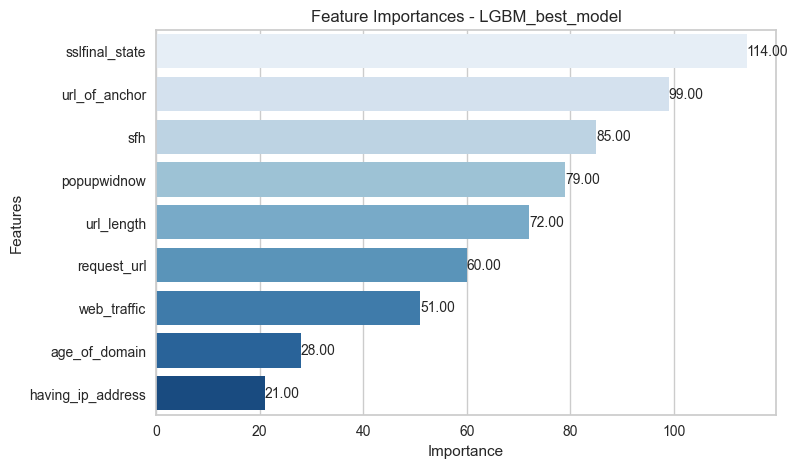

In [18]:
# Feature Importance
plot_feature_importance(LGBM_best_model, X_test, 'LGBM_best_model')

In [22]:
# Save LightGBM model
import joblib

joblib.dump(LGBM_best_model, 'LGBM_best_model.joblib')
print("Model saved successfully")

Model saved successfully


In [23]:
import pickle
with open('LGBM_best_model.pkl', 'wb') as f:
    pickle.dump(model, f)

## 2. RandomForest Classifier

In [24]:
# RF Hyperparameters Tuning with GridSearchSV 

# Reset the model
model = RandomForestClassifier(random_state=random_state)


param_grid = {           
            'n_estimators': [50,100],  
            'max_depth': [None, 2, 10],
            'min_samples_split': [5, 10],
            'min_samples_leaf': [2,5],
            'max_features': ['sqrt', 'log2'],
            'max_samples':[0.5, 0.9],
            "criterion": ["gini", "entropy"]
             }
             


cv = StratifiedKFold(n_splits=5)

# GridSearchCV
RFC_grid_model = GridSearchCV(model,
                          param_grid=param_grid,
                          cv=cv,
                          scoring="accuracy",  
                          n_jobs=4,          # Use all available cores
                          verbose=1,
                          return_train_score=True).fit(X_train, y_train) # Fit the grid search model

Fitting 5 folds for each of 192 candidates, totalling 960 fits


In [25]:
rfc_best_params = RFC_grid_model.best_params_
rfc_best_scores = RFC_grid_model.best_score_
print('Best Params:', rfc_best_params)
print('Best Recall Score(test):', rfc_best_scores)
print('-----------------------------------------------------')

# Checking overfiting of Grid Model with the CV scores
pd.DataFrame(RFC_grid_model.cv_results_).loc[RFC_grid_model.best_index_, ["mean_test_score", "mean_train_score"]] # type: ignore

Best Params: {'criterion': 'entropy', 'max_depth': None, 'max_features': 'sqrt', 'max_samples': 0.9, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 100}
Best Recall Score(test): 0.9158986175115207
-----------------------------------------------------


mean_test_score     0.915899
mean_train_score    0.942236
Name: 107, dtype: float64

### Prediction with Best HyperParameters

In [26]:
# Create a new model with the best parameters from GridSearchCV
RFC_best_model  = RandomForestClassifier(
    **rfc_best_params,  # Unpack the best parameters dictionary
    random_state=random_state,
    #verbose=1
)

# Fit the model on the training data
RFC_best_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'entropy'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `me

In [27]:
# Make predictions on test data
y_pred = RFC_best_model.predict(X_test)

# Evaluate the model
RFC_best_acc = accuracy_score(y_test, y_pred)
print('RFC_best_model_accuracy score with the Test prediction: ',RFC_best_acc, '\n')

target_names = ['Phishing', 'Legitamite']
print(classification_report(y_test, y_pred, target_names=target_names))

RFC_best_model_accuracy score with the Test prediction:  0.915129151291513 

              precision    recall  f1-score   support

    Phishing       0.94      0.91      0.93       161
  Legitamite       0.88      0.92      0.90       110

    accuracy                           0.92       271
   macro avg       0.91      0.92      0.91       271
weighted avg       0.92      0.92      0.92       271



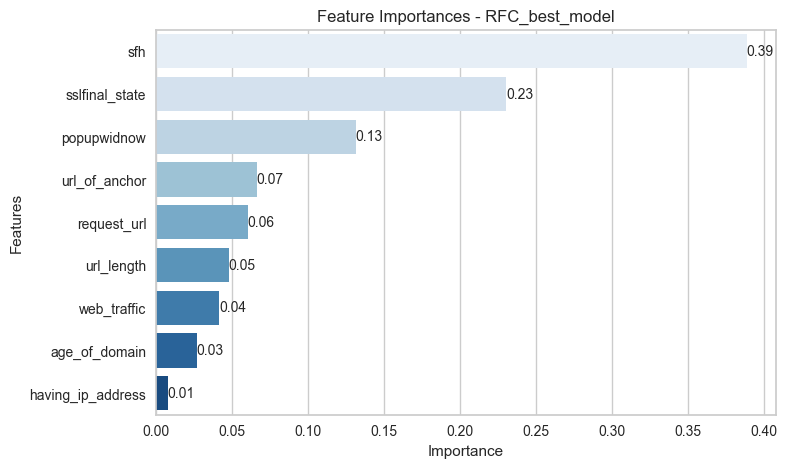

In [28]:
# Feature Importance
plot_feature_importance(RFC_best_model, X_test, 'RFC_best_model')

In [29]:
# Save Random Forest model

import joblib

joblib.dump(RFC_best_model, 'RFC_best_model.joblib')
print("Model saved successfully")

Model saved successfully


In [30]:
import pickle
with open('RFC_best_model.pkl', 'wb') as f:
    pickle.dump(RFC_best_model, f)

## 3. XGBoost Classifier

In [31]:
# XGBoosting Hyperparameters Tuning with GridSearchSV 
from xgboost import XGBClassifier

# Reset the model
model = XGBClassifier(random_state=random_state, verbose=-1)

# Define the hyperparameters grid for tuning
param_grid = {
    "booster": ['dart', 'gbtree'],
    "eta": [0.05, 0.1],
    "n_estimators": [100, 150],
    'max_depth': [2, 3],
    "learning_rate": [0.05, 0.1],
    "subsample": [0.6, 0.8],
    "colsample_bytree": [0.6, 0.8],
    'reg_alpha': [0, 0.5]
}

cv = StratifiedKFold(n_splits=5)

# GridSearchCV
XGB_grid_model  = GridSearchCV(model,
                          param_grid=param_grid,
                          cv=cv,
                          scoring="accuracy",   
                          n_jobs=4,          # Use all available cores
                          verbose=1,
                          return_train_score=True).fit(X_train, y_train) # Fit the grid search model

Fitting 5 folds for each of 256 candidates, totalling 1280 fits
[16:11:19] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "verbose" } are not used.

[16:11:19] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "verbose" } are not used.

[16:11:19] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "verbose" } are not used.

[16:11:19] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "verbose" } are not used.

[16:11:20] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "verbose" } are not used.

[16:11:20] WARNING: /Users/runner/wo

In [32]:
xgb_best_params = XGB_grid_model.best_params_
xgb_best_scores = XGB_grid_model.best_score_
print('Best Params:', xgb_best_params)
print('Best Recall Score(test):', xgb_best_scores)
print('-----------------------------------------------------')

# Checking overfiting of Grid Model with the CV scores
pd.DataFrame(XGB_grid_model.cv_results_).loc[XGB_grid_model.best_index_, ["mean_test_score", "mean_train_score"]] # type: ignore

Best Params: {'booster': 'gbtree', 'colsample_bytree': 0.8, 'eta': 0.05, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 150, 'reg_alpha': 0.5, 'subsample': 0.8}
Best Recall Score(test): 0.9140595664789213
-----------------------------------------------------


mean_test_score     0.914060
mean_train_score    0.939693
Name: 223, dtype: float64

### Prediction with Best HyperParameters

In [33]:
# Create a new XGB model with the best parameters from GridSearchCV
XGB_best_model  = XGBClassifier(
    **xgb_best_params,  # Unpack the best parameters dictionary
    random_state=random_state,
    verbose=1
)

# Fit the model on the training data
XGB_best_model.fit(X_train, y_train)

[16:11:57] WARNING: /Users/runner/work/xgboost/xgboost/python-package/build/temp.macosx-11.0-arm64-cpython-38/xgboost/src/learner.cc:767: 
Parameters: { "verbose" } are not used.



,objective,'binary:logistic'
,use_label_encoder,None
,base_score,None
,booster,'gbtree'
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [34]:
# Make predictions on test data
y_pred = XGB_best_model.predict(X_test)

# Evaluate the model
XGB_best_acc = accuracy_score(y_test, y_pred)
print('XGB_best_model_accuracy score with the Test prediction: ',XGB_best_acc, '\n')

target_names = ['Phishing', 'Legitamite']
print(classification_report(y_test, y_pred, target_names=target_names))

XGB_best_model_accuracy score with the Test prediction:  0.9077490774907749 

              precision    recall  f1-score   support

    Phishing       0.95      0.89      0.92       161
  Legitamite       0.86      0.93      0.89       110

    accuracy                           0.91       271
   macro avg       0.90      0.91      0.91       271
weighted avg       0.91      0.91      0.91       271



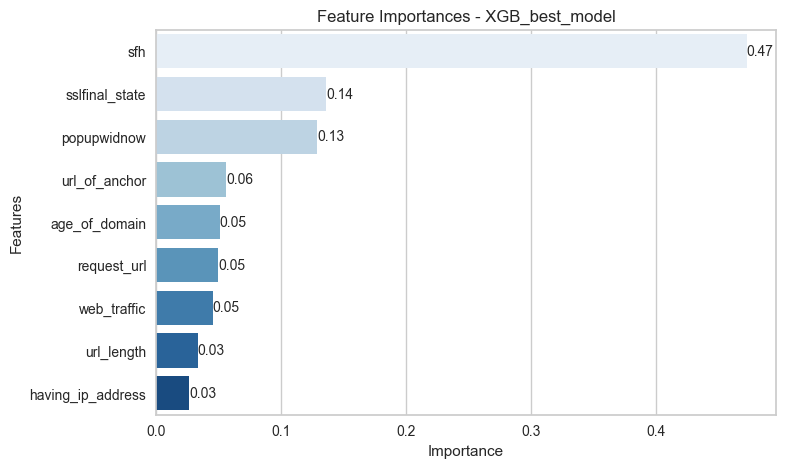

In [35]:
# Feature Importance
plot_feature_importance(XGB_best_model, X_test, 'XGB_best_model')

In [36]:
# Save Random Forest model

import joblib

joblib.dump(XGB_best_model, 'XGB_best_model.joblib')
print("Model saved successfully")

Model saved successfully


In [37]:
import pickle
with open('XGB_best_model.pkl', 'wb') as f:
    pickle.dump(XGB_best_model, f)

## Stacking Ensemble Models

In [38]:
# Define base models
base_models = [
    ('rf', RandomForestClassifier(**rfc_best_params,random_state=random_state)),
    ('xgb', XGBClassifier(**xgb_best_params,random_state=random_state, use_label_encoder=False, eval_metric='logloss')),
    ('lgbm', LGBMClassifier(**lgbm_best_params, random_state=random_state, verbose=-1))
]

# Define meta model
meta_model = LogisticRegression(random_state=random_state)

# Create the StackingClassifier
stacking_model = StackingClassifier(estimators=base_models, final_estimator=meta_model, cv=5)

In [39]:
# Define the parameter grid for GridSearch
param_grid = {
    # Meta-learner parameters
    'final_estimator__C': [0.1, 1.0, 10.0],
    'final_estimator__solver': ['liblinear', 'saga']
}

cv = StratifiedKFold(n_splits=5)

# Apply GridSearchCV
STACK_grid_model = GridSearchCV(estimator=stacking_model,
                           param_grid=param_grid,
                           scoring="accuracy",
                           cv=cv,
                           n_jobs=-1,
                           verbose=1)

# Fit the model
STACK_grid_model.fit(X_train, y_train)

Fitting 5 folds for each of 6 candidates, totalling 30 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",StackingClass...dom_state=42))
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'final_estimator__C': [0.1, 1.0, ...], 'final_estimator__solver': ['liblinear', 'saga']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo...shuffle=False)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and paramete

In [40]:
stack_best_params = STACK_grid_model.best_params_
stack_best_scores = STACK_grid_model.best_score_
print('Best Params:', stack_best_params)
print('Best Recall Score(test):', stack_best_scores)
print('-----------------------------------------------------')

Best Params: {'final_estimator__C': 10.0, 'final_estimator__solver': 'liblinear'}
Best Recall Score(test): 0.9168202764976959
-----------------------------------------------------


### Prediction with Best HyperParameters

In [41]:
# Create the best meta-learner with optimized parameters
best_meta_model = LogisticRegression(
    C=stack_best_params['final_estimator__C'],
    solver=stack_best_params['final_estimator__solver'],
    random_state=random_state,
    verbose=1
)

# Create the best stacking model
STACK_best_model = StackingClassifier(
    estimators=base_models,
    final_estimator=best_meta_model,
    cv=5
)

# Fit the model on the training data
STACK_best_model.fit(X_train, y_train)

[LibLinear]iter  1 act 4.496e+03 pre 4.006e+03 delta 3.606e+00 f 7.500e+03 |g| 2.658e+03 CG   2
iter  2 act 5.162e+02 pre 4.314e+02 delta 3.606e+00 f 3.004e+03 |g| 5.751e+02 CG   2
iter  3 act 8.153e+01 pre 7.181e+01 delta 3.606e+00 f 2.488e+03 |g| 1.581e+02 CG   2
cg reaches trust region boundary
iter  4 act 2.988e+01 pre 2.940e+01 delta 3.782e+00 f 2.406e+03 |g| 3.253e+01 CG   4
iter  5 act 1.253e+00 pre 1.245e+00 delta 3.782e+00 f 2.376e+03 |g| 6.612e+00 CG   4
iter  6 act 8.902e-05 pre 8.900e-05 delta 3.782e+00 f 2.375e+03 |g| 2.572e-01 CG   2


,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.The type of estimator is generally expected to be a classifier.However, one can pass a regressor for some use case (e.g. ordinalregression).","[('rf', ...), ('xgb', ...), ...]"
,"final_estimator final_estimator: estimator, default=NoneA classifier which will be used to combine the base estimators.The default classifier is a:class:`~sklearn.linear_model.LogisticRegression`.","LogisticRegre...r', verbose=1)"
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",5
,"stack_method stack_method: {'auto', 'predict_proba', 'decision_function', 'predict'}, default='auto'Methods called for each base estimator. It can be:* if 'auto', it will try to invoke, for each estimator, `'predict_proba'`, `'decision_function'` or `'predict'` in that order.* otherwise, one of `'predict_proba'`, `'decision_function'` or `'predict'`. If the method is not implemented by the estimator, it will raise an error.",'auto'
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary ` for more details.",None
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'entropy'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum numbe

In [42]:
# Make predictions on test data
y_pred = STACK_best_model.predict(X_test)

# Evaluate the model
STACK_best_acc = accuracy_score(y_test, y_pred)
print('STACK_best_model_accuracy score with the Test prediction: ',STACK_best_acc, '\n')

target_names = ['Phishing', 'Legitamite']
print(classification_report(y_test, y_pred, target_names=target_names))

STACK_best_model_accuracy score with the Test prediction:  0.922509225092251 

              precision    recall  f1-score   support

    Phishing       0.95      0.92      0.93       161
  Legitamite       0.89      0.93      0.91       110

    accuracy                           0.92       271
   macro avg       0.92      0.92      0.92       271
weighted avg       0.92      0.92      0.92       271



# Comparing all the Models

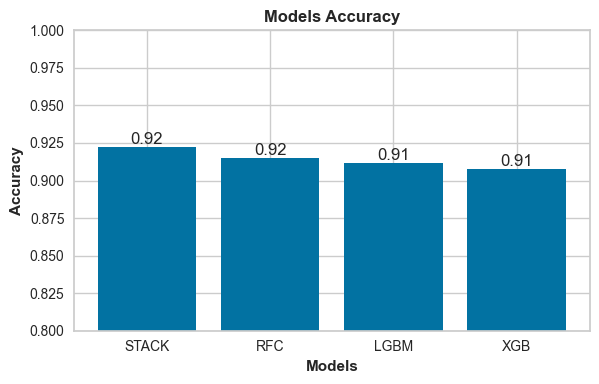

In [ ]:
# All the Models Accuracy Scores
accuracy_dict = {
    'RFC': RFC_best_acc,
    'XGB': XGB_best_acc,
    'LGBM': LGBM_best_acc,
    'STACK': STACK_best_acc
}

sorted_accuracy_dict = dict(sorted(accuracy_dict.items(), key=lambda item: item[1], reverse=True))

# Plotting accuracy scores
plt.figure(figsize=(6, 4))
bars = plt.bar(list(sorted_accuracy_dict.keys()), list(sorted_accuracy_dict.values())) # type: ignore

# Adding annotations
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, round(height, 2), ha='center', va='bottom')

plt.xlabel('Models', fontweight='bold')
plt.ylabel('Accuracy', fontweight='bold')
plt.title('Models Accuracy', fontweight='bold')
plt.tight_layout()
plt.ylim(0.8, 1)
plt.show()

# Final Model

RandomForestClassification and Stack shows 92 % accuracy. we choose RandomForestClassification

In [44]:
# Load the model with best parameters
RFC_model_loaded = joblib.load('RFC_best_model.joblib')
print("Model loaded successfully")

RFC_model_loaded

Model loaded successfully


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'entropy'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `me

In [46]:
# Make predictions on test data
y_pred = RFC_model_loaded.predict(X_test)

# Evaluate the model
RFC_best_acc = accuracy_score(y_test, y_pred)
print('RFC_best_model_accuracy score with the Test prediction: ',RFC_best_acc, '\n')

target_names = ['Phishing', 'Legitamite']
print(classification_report(y_test, y_pred, target_names=target_names))

RFC_best_model_accuracy score with the Test prediction:  0.915129151291513 

              precision    recall  f1-score   support

    Phishing       0.94      0.91      0.93       161
  Legitamite       0.88      0.92      0.90       110

    accuracy                           0.92       271
   macro avg       0.91      0.92      0.91       271
weighted avg       0.92      0.92      0.92       271



<Figure size 600x400 with 0 Axes>

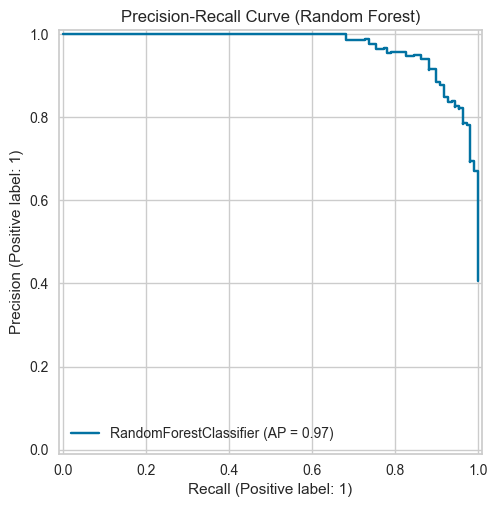

In [49]:
# Precision Recall Curve
plt.figure(figsize=(6,4))

PrecisionRecallDisplay.from_estimator(
    RFC_model_loaded,
    X_test,
    y_test
)

plt.title("Precision-Recall Curve (Random Forest)")
plt.show()

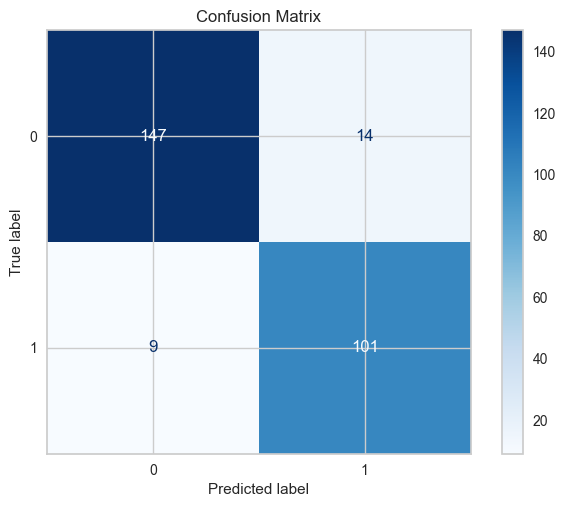

In [50]:

# Confusion Matrix
ConfusionMatrixDisplay.from_estimator(
    RFC_model_loaded,
    X_test,
    y_test,
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.show()

# Conclusion

RandomForestClassifier model performance:

- RFC model shows strong performance in classifying phishing versus legitimate cases:

    - **Accuracy**: 91.5% accuracy on the test set, meaning the model correctly classified about 9 out of 10 samples overall.
    - **Phishing Detection**: 94% precision and 91% recall for phishing cases. This means when the model predicts something is phishing, it's right 94% of the time, and it catches 91% of all actual phishing instances.
    - **Legitimate Classification**: 88% precision and 92% recall for legitimate cases. The model is slightly better at identifying legitimate cases (higher recall) than being confident about them (lower precision).
    - **Precision-Recall Curve**: The first image shows an excellent PR curve with an average precision of 0.97. The curve remains high across different recall thresholds, dropping only at very high recall values.
    - **Confusion Matrix**: The second image confirms excellent performance with 147 true negatives and 101 true positives. There are only 14 false positives and 9 false negatives.

In summary, this model performs very well for phishing detection with balanced precision and recall, making it reliable for practical application.